# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn datasets transformers evaluate pyvi accelerate

%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [3]:
# import thu vien
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from pyvi import ViTokenizer
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

warnings.filterwarnings('ignore')


## Tải dữ liệu

In [4]:
# doc du lieu
DATA_DIR = str(PROJECT_ROOT / "data" / "processed")
MODEL_DIR = str(PROJECT_ROOT / "outputs" / "models" / "phobert_base")
FIG_DIR = str(PROJECT_ROOT / "outputs" / "figures")
METRIC_DIR = str(PROJECT_ROOT / "outputs" / "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, 'train_processed.csv')
VAL_PATH = os.path.join(DATA_DIR, 'val_processed.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test_processed.csv')

TEXT_COL = 'text_clean'
LABEL_COL = 'label_id'
MODEL_NAME = 'vinai/phobert-base'
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cuda'

In [5]:
# doc du lieu
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df.shape, val_df.shape, test_df.shape

((24046, 5), (2672, 5), (6680, 5))

In [6]:
# kiem tra cot du lieu
assert TEXT_COL in train_df.columns and LABEL_COL in train_df.columns
assert TEXT_COL in val_df.columns and LABEL_COL in val_df.columns
assert TEXT_COL in test_df.columns and LABEL_COL in test_df.columns

train_df[[TEXT_COL, LABEL_COL]].head()

,text_clean,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


## Tiền xử lý

In [7]:
# tach tu cho phobert
def segment_text(text):
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ViTokenizer.tokenize(text)

train_df['text_seg'] = train_df[TEXT_COL].apply(segment_text)
val_df['text_seg'] = val_df[TEXT_COL].apply(segment_text)
test_df['text_seg'] = test_df[TEXT_COL].apply(segment_text)

train_df[['text_seg', LABEL_COL]].head()

,text_seg,label_id
0,Em được làm fan cứng luôn rồi nè ❤ ️ reaction ...,0
1,Đúng là bọn mắt híp lò_xo thụt : ) ) ) bên việ...,2
2,Đậu_Văn Cường giờ giống thằng sida hơn à,0
3,CÔN_ĐỒ CỤC_SÚC VÔ NHÂN_TÍNH ĐỀ NGHI VN. NHÀ_NƯ...,2
4,Từ lý_thuyết đến thực_hành là cả 1 câu_chuyện ...,0


In [8]:
# thong ke do dai
seg_len = train_df['text_seg'].str.split().str.len()
length_stats = pd.Series({
    'mean': round(seg_len.mean(), 2),
    'median': round(seg_len.median(), 2),
    'p95': round(seg_len.quantile(0.95), 2),
    'p99': round(seg_len.quantile(0.99), 2),
    'max': int(seg_len.max())
})
length_stats

mean        11.51
median       8.00
p95         32.00
p99         58.00
max       1722.00
dtype: float64

In [9]:
# tham so huan luyen
MAX_LEN = 128
BATCH_SIZE = 16
LR = 2e-5
EPOCHS = 4
NUM_LABELS = 3
LABEL_MAP = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df[LABEL_COL].unique())),
    y=train_df[LABEL_COL].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([0.4031, 4.9940, 3.1359])

## Bộ tách từ

In [10]:
# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(texts):
    return tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=MAX_LEN
    )

In [11]:
# tao dataset
class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.texts = df['text_seg'].tolist()
        self.labels = df[LABEL_COL].astype(int).tolist()
        self.encodings = tokenize_batch(self.texts)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = ToxicDataset(train_df)
val_ds = ToxicDataset(val_df)
test_ds = ToxicDataset(test_df)

len(train_ds), len(val_ds), len(test_ds)

(24046, 2672, 6680)

## Mô hình

In [12]:
# metric
LABEL_NAMES = ['CLEAN', 'OFFENSIVE', 'HATE']

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [13]:
# model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'},
    label2id={'CLEAN': 0, 'OFFENSIVE': 1, 'HATE': 2}
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=os.path.join(MODEL_DIR, 'checkpoint'),
    overwrite_output_dir=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
# train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.873400,0.805188,0.843937,0.627324,0.664105,0.643438
2,0.647100,0.748268,0.829341,0.620351,0.712609,0.655487
3,0.512400,0.880021,0.854416,0.657462,0.699264,0.674639
4,0.416200,1.019312,0.852545,0.650863,0.699455,0.672370


TrainOutput(global_step=6012, training_loss=0.6122846470145646, metrics={'train_runtime': 923.609, 'train_samples_per_second': 104.139, 'train_steps_per_second': 6.509, 'total_flos': 2217222854229852.0, 'train_loss': 0.6122846470145646, 'epoch': 4.0})

In [21]:
# lich su train
log_history = pd.DataFrame(trainer.state.log_history)
log_history.tail()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
5,NaN,NaN,NaN,3.0,4509,0.880021,0.854416,0.657462,0.699264,0.674639,4.2153,633.887,39.618,NaN,NaN,NaN,NaN,NaN
6,0.4162,35.531445,2.994012e-08,4.0,6012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,6012,1.019312,0.852545,0.650863,0.699455,0.672370,4.2034,635.675,39.730,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,4.0,6012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,923.609,104.139,6.509,2.217223e+15,0.612285
9,NaN,NaN,NaN,4.0,6012,0.880021,0.854416,0.657462,0.699264,0.674639,4.2147,633.977,39.624,NaN,NaN,NaN,NaN,NaN


## Đánh giá

In [22]:
# ket qua tren dev
dev_metrics = trainer.evaluate(eval_dataset=val_ds)
pd.DataFrame([dev_metrics])

,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.880021,0.854416,0.657462,0.699264,0.674639,4.4492,600.558,37.535,4.0


In [23]:
# du doan tren test
pred_output = trainer.predict(test_ds)
test_logits = pred_output.predictions
test_pred = np.argmax(test_logits, axis=1)
y_test = test_df[LABEL_COL].astype(int).values

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, test_pred, average='macro', zero_division=0)
acc = accuracy_score(y_test, test_pred)

metrics_df = pd.DataFrame([
    {
        'accuracy': round(acc, 4),
        'precision_macro': round(p_macro, 4),
        'recall_macro': round(r_macro, 4),
        'f1_macro': round(f1_macro, 4)
    }
])
metrics_df

,accuracy,precision_macro,recall_macro,f1_macro
0,0.8588,0.6496,0.6936,0.6658


In [18]:
# bao cao theo lop
report = classification_report(
    y_test,
    test_pred,
    target_names=LABEL_NAMES,
    digits=4,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
CLEAN,0.946965,0.914023,0.930203,5548.000000
OFFENSIVE,0.381317,0.560811,0.453965,444.000000
HATE,0.620536,0.606105,0.613235,688.000000
accuracy,0.858832,0.858832,0.858832,0.858832
macro avg,0.649606,0.693646,0.665801,6680.000000
weighted avg,0.875748,0.858832,0.865903,6680.000000


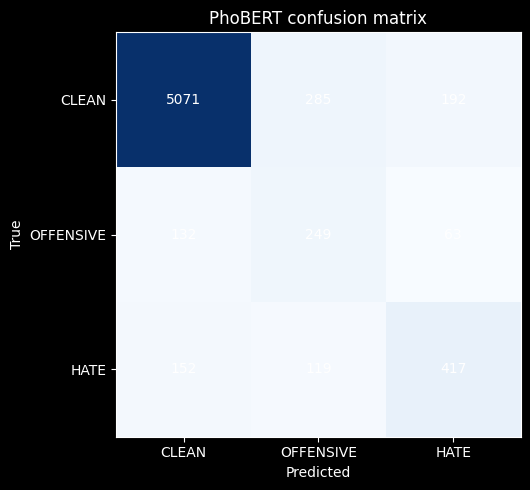

In [19]:
# ve confusion matrix
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('PhoBERT confusion matrix')
plt.xticks(range(len(LABEL_NAMES)), LABEL_NAMES)
plt.yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phobert_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

## Lưu kết quả

In [20]:
# luu ket qua
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

metrics_df.to_csv(os.path.join(METRIC_DIR, 'phobert_metrics.csv'), index=False)
report_df.to_csv(os.path.join(METRIC_DIR, 'phobert_classification_report.csv'))
log_history.to_csv(os.path.join(METRIC_DIR, 'phobert_train_log.csv'), index=False)

test_out = test_df[[TEXT_COL, LABEL_COL]].copy()
test_out['pred_id'] = test_pred
test_out['pred_label'] = test_out['pred_id'].map(LABEL_MAP)
test_out['true_label'] = test_out[LABEL_COL].map(LABEL_MAP)
test_out.to_csv(os.path.join(METRIC_DIR, 'phobert_test_predictions.csv'), index=False)
